In [ ]:
import pyspark

In [ ]:
from google.colab import files

In [ ]:
uploaded=files.upload()

Saving dataset.csv to dataset.csv


In [ ]:
from pyspark.sql import *
from pyspark.sql.functions import *

In [ ]:
spark=SparkSession.builder.appName('uber_analytics').getOrCreate()


In [ ]:
df=spark.read.csv('dataset.csv',inferSchema=True,header=True)

In [ ]:
df_updated = df.withColumn('row_id',monotonically_increasing_id())
windowSpec = Window.orderBy("row_id").rowsBetween(Window.unboundedPreceding, 0)
df_updated = df_updated.withColumn(
    "Date",
    last(col("Date"), ignorenulls=True).over(windowSpec)
)


df_updated = df_updated.drop('row_id')

Find the busiest consecutive 3-hour windowa

In [ ]:
import pyspark.sql.functions as F

In [ ]:
windowspec = Window.orderBy('Date','Time (Local)').rowsBetween(0,2)

In [ ]:
df_busies = df_updated.withColumn(
            'Busiest',
            F.sum('Requests ').over(windowspec)
)

In [ ]:
df_busies.show()

+---------+------------+---------+-------+----------------+---------+--------------+-------+
|     Date|Time (Local)|Eyeballs |Zeroes |Completed Trips |Requests |Unique Drivers|Busiest|
+---------+------------+---------+-------+----------------+---------+--------------+-------+
|10-Sep-12|           7|        5|      0|               2|        2|             9|      4|
|10-Sep-12|           8|        6|      0|               2|        2|            14|      3|
|10-Sep-12|           9|        8|      3|               0|        0|            14|      5|
|10-Sep-12|          10|        9|      2|               0|        1|            14|      7|
|10-Sep-12|          11|       11|      1|               4|        4|            11|      6|
|10-Sep-12|          12|       12|      0|               2|        2|            11|      2|
|10-Sep-12|          13|        9|      1|               0|        0|             9|      2|
|10-Sep-12|          14|       12|      1|               0|        0| 

In [ ]:
busies = df_busies.orderBy('Busiest',ascending=False).first()

In [ ]:
start_hour = busies['Time (Local)']
end_hour = start_hour + 2

In [ ]:
print(f"The Busiest date was {busies['Date']} at {busies['Time (Local)']} to {end_hour} hour and the request was {busies['Requests ']}")

The Busiest date was 22-Sep-12 at 22 to 24 hour and the request was 33


Calculate rolling 3-hour average of completed trips

In [ ]:
roll_back_window = Window.orderBy('Date','Time (Local)').rowsBetween(-2,0)

In [ ]:
df_roll_back = df_updated.withColumn(
            'Rolling_Average',
           F.round(F.avg('Completed Trips ').over(roll_back_window),2)
)


In [ ]:
df_roll_back.show()

+---------+------------+---------+-------+----------------+---------+--------------+---------------+
|     Date|Time (Local)|Eyeballs |Zeroes |Completed Trips |Requests |Unique Drivers|Rolling_Average|
+---------+------------+---------+-------+----------------+---------+--------------+---------------+
|10-Sep-12|           7|        5|      0|               2|        2|             9|            2.0|
|10-Sep-12|           8|        6|      0|               2|        2|            14|            2.0|
|10-Sep-12|           9|        8|      3|               0|        0|            14|           1.33|
|10-Sep-12|          10|        9|      2|               0|        1|            14|           0.67|
|10-Sep-12|          11|       11|      1|               4|        4|            11|           1.33|
|10-Sep-12|          12|       12|      0|               2|        2|            11|            2.0|
|10-Sep-12|          13|        9|      1|               0|        0|             9|       

In [ ]:
df_roll_back.select(
    "Date",
    "Time (Local)",
    "Completed Trips ",
    "Rolling_Average"
).orderBy("Date", "Time (Local)").show()

+---------+------------+----------------+---------------+
|     Date|Time (Local)|Completed Trips |Rolling_Average|
+---------+------------+----------------+---------------+
|10-Sep-12|           7|               2|            2.0|
|10-Sep-12|           8|               2|            2.0|
|10-Sep-12|           9|               0|           1.33|
|10-Sep-12|          10|               0|           0.67|
|10-Sep-12|          11|               4|           1.33|
|10-Sep-12|          12|               2|            2.0|
|10-Sep-12|          13|               0|            2.0|
|10-Sep-12|          14|               0|           0.67|
|10-Sep-12|          15|               1|           0.33|
|10-Sep-12|          16|               3|           1.33|
|10-Sep-12|          17|               3|           2.33|
|10-Sep-12|          18|               3|            3.0|
|10-Sep-12|          19|               2|           2.67|
|10-Sep-12|          20|               0|           1.67|
|10-Sep-12|   

Identify times when demand exceeded supply (high Zeroes)

In [ ]:
avg_Zero = df_updated.agg(F.avg(('Zeroes '))).first()[0]

In [ ]:
print(avg_Zero)

4.252976190476191


In [ ]:

df_updated.filter(df_updated['Zeroes '] > avg_Zero).show()

+---------+------------+---------+-------+----------------+---------+--------------+
|     Date|Time (Local)|Eyeballs |Zeroes |Completed Trips |Requests |Unique Drivers|
+---------+------------+---------+-------+----------------+---------+--------------+
|10-Sep-12|          23|       21|      5|               3|        3|             4|
|11-Sep-12|          17|       23|      5|               0|        0|             9|
|11-Sep-12|          21|       19|      6|               5|        5|             5|
|11-Sep-12|          22|       26|     10|               2|        6|             2|
|11-Sep-12|          23|       15|     12|               0|        3|             1|
|12-Sep-12|           7|       10|      5|               2|        5|             4|
|12-Sep-12|          23|       14|      6|               2|        5|             3|
|13-Sep-12|           0|       11|     11|               0|        2|             0|
|13-Sep-12|           1|        6|      6|               0|      

Check for any hours with zero activity across all metrics

In [ ]:
df_updated.filter((df_updated['Requests '] == 0) & (df_updated['Completed Trips ']==0) & (df_updated['Zeroes ']==0) & (df_updated['Eyeballs ']==0)) .show()

+---------+------------+---------+-------+----------------+---------+--------------+
|     Date|Time (Local)|Eyeballs |Zeroes |Completed Trips |Requests |Unique Drivers|
+---------+------------+---------+-------+----------------+---------+--------------+
|21-Sep-12|           4|        0|      0|               0|        0|             0|
+---------+------------+---------+-------+----------------+---------+--------------+





Find outlier days (unusually high or low activity)


In [ ]:
std_req = df_updated.agg(stddev('Requests ')).first()[0]

In [ ]:
mean_req = df_updated.agg(avg('Requests ')).first()[0]

In [ ]:
df_updated.filter((df_updated['Requests '] > mean_req + 2*std_req) | (df_updated['Requests ']<mean_req -2*std_req)).show()

+---------+------------+---------+-------+----------------+---------+--------------+
|     Date|Time (Local)|Eyeballs |Zeroes |Completed Trips |Requests |Unique Drivers|
+---------+------------+---------+-------+----------------+---------+--------------+
|14-Sep-12|          23|       68|     18|              24|       29|            18|
|15-Sep-12|           0|       45|      2|              23|       24|            19|
|15-Sep-12|           2|       38|     17|              22|       27|            12|
|15-Sep-12|          18|       59|     25|              15|       25|            10|
|15-Sep-12|          19|       73|     38|              17|       34|            14|
|15-Sep-12|          22|       69|     26|              24|       34|            16|
|15-Sep-12|          23|       61|     32|              16|       24|            13|
|21-Sep-12|          17|       68|     25|              26|       26|            20|
|21-Sep-12|          18|       62|      6|              15|      

Calculate standard deviation of requests by hour

In [ ]:
df_std_req = df_updated.groupBy('Time (Local)').agg(stddev('Requests ').alias('std_dev')).orderBy('Time (Local)').show()

+------------+------------------+
|Time (Local)|           std_dev|
+------------+------------------+
|           0|11.155248111967767|
|           1|  8.74297205986388|
|           2| 8.636747454534408|
|           3|2.8756270219259603|
|           4|1.0818177620697813|
|           5|1.1094003924504583|
|           6|1.3008872711759818|
|           7|1.3985864135061357|
|           8| 2.164904890939366|
|           9|1.8752289237539816|
|          10|0.9607689228305228|
|          11|2.4053511772118195|
|          12| 3.555679561329612|
|          13| 4.795258647300007|
|          14| 5.635932599289692|
|          15|5.9544977920932975|
|          16| 4.400299690093546|
|          17| 6.226494259953251|
|          18| 7.282750959524947|
|          19|   9.1555543701174|
+------------+------------------+
only showing top 20 rows


Create hourly heatmap data (Date vs Hour vs Completed Trips)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_updated.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Time (Local): integer (nullable = true)
 |-- Eyeballs : integer (nullable = true)
 |-- Zeroes : integer (nullable = true)
 |-- Completed Trips : integer (nullable = true)
 |-- Requests : integer (nullable = true)
 |-- Unique Drivers: integer (nullable = true)



In [ ]:
df_updated=df_updated.withColumn('Date',to_date('Date','dd-MMM-yy'))

In [ ]:
heatmap_Data =df_updated.select(col('Date'),(col('Time (Local)')).alias('hour'),col('Completed Trips ')).orderBy('Date','hour')

In [ ]:
heatmap_pd = heatmap_Data.toPandas()

In [ ]:
heatmap_pivot = heatmap_pd.pivot(
    index="Date",
    columns="hour",
    values="Completed Trips "
)

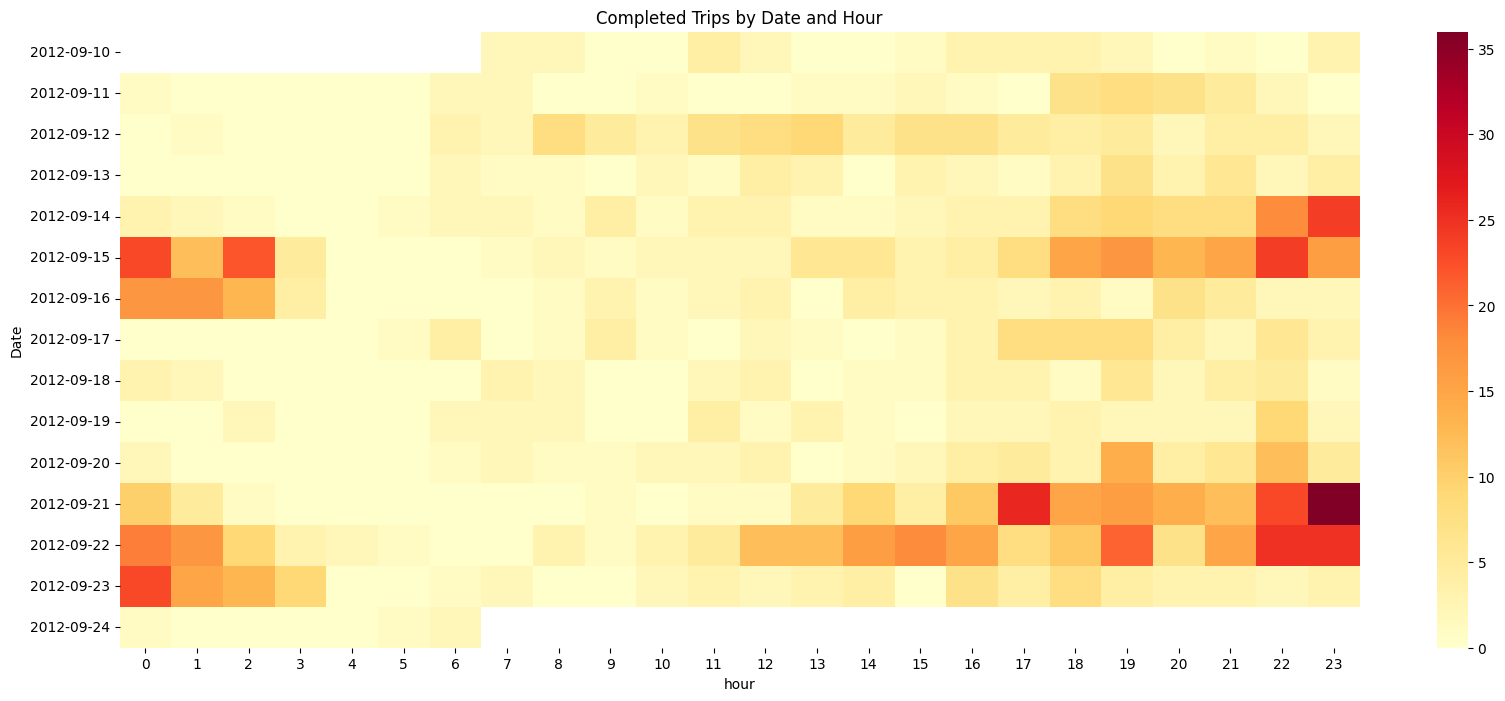

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_pivot, cmap="YlOrRd")
plt.title("Completed Trips by Date and Hour")
plt.show()